# Case no. 1 - air line blockage
Out of six options, we choose the first fault case. 

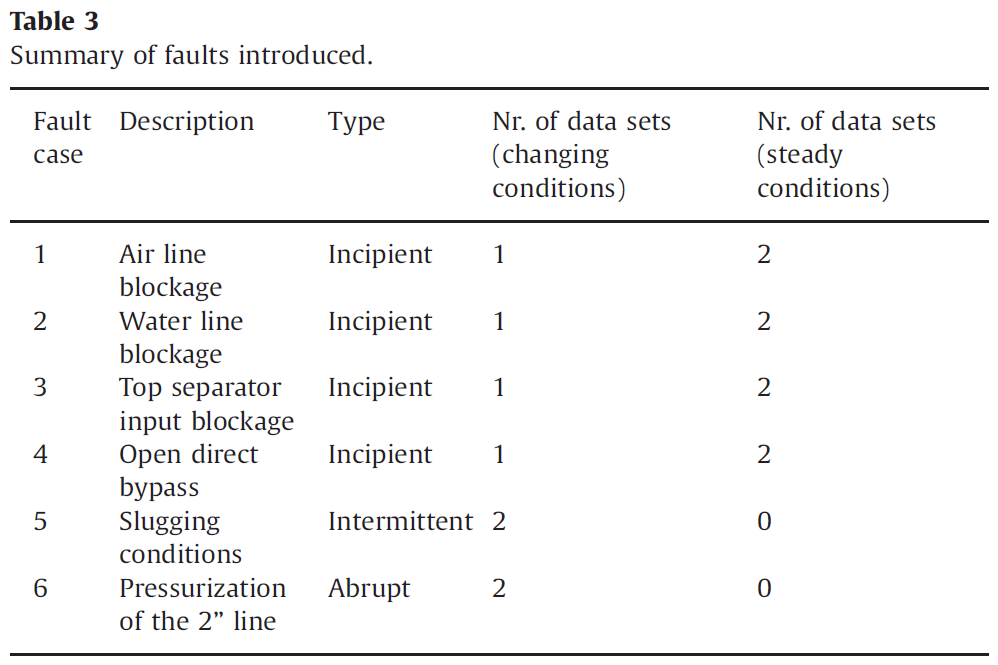

After the fault was introduced to the system, the operation ran with three different configurations. This provides the three data sets called Set1_1, Set1_2 and Set1_3. 
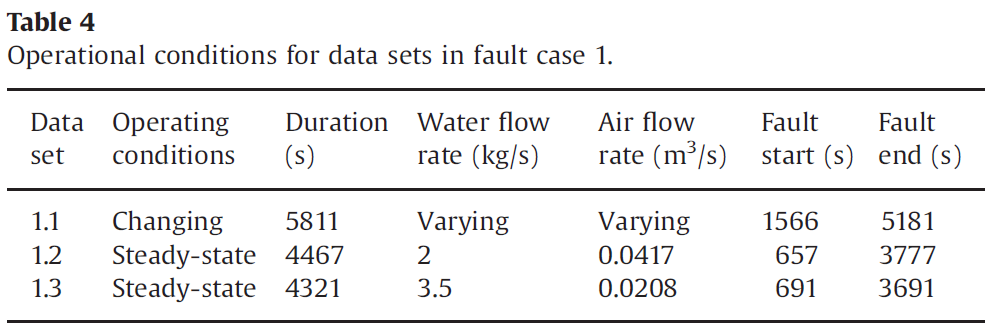

The fault that got introduced to the system is related to the valve position, which can be observed by the three fault data sets. This variable is not available in the training data. 
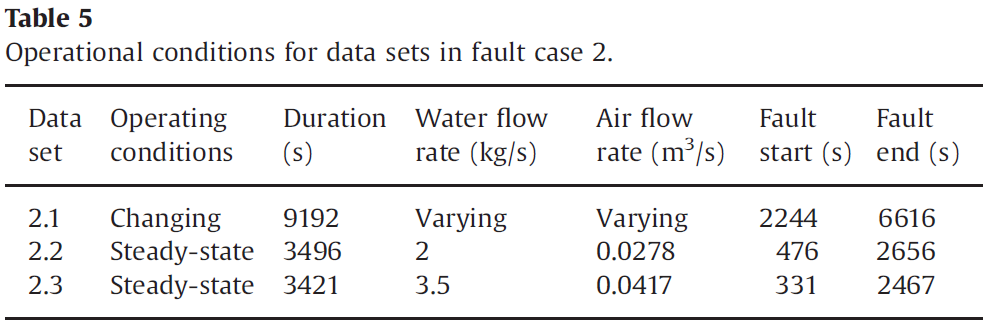

# Loading the data
Operational data - Loaded seperatly and pooled together for a more robust training. 

In [1]:
import scipy.io
import pandas as pd

# 1. Indlæs filen
mat_data = scipy.io.loadmat('CVACaseStudy/FaultyCase1.mat')

# 2. Definer kolonnenavne (v1-v23 jf. Table 1 i artiklen)
# Vi udelader v24 (P_Mixture_2in), da den kun er til Case 6 [cite: 251]
column_names = [
    "Air_Delivery_P", "P_Bottom_Riser", "P_Top_Riser", "P_Top_Separator", 
    "P_3Phase_Separator", "Diff_P_Riser", "Diff_P_VC404", "Air_In_Flow", 
    "Water_In_Flow", "Flow_Top_Riser", "Level_Top_Sep", "Flow_Top_Sep_Out", 
    "Density_Top_Riser", "Density_Top_Sep_Out", "Density_Water_In", 
    "Temp_Top_Riser", "Temp_Top_Sep_Out", "Temp_Water_In", "Level_3Phase_Sep", 
    "Pos_VC501", "Pos_VC302", "Pos_VC101", "Pump_Current_PO1"
]

# 3. Indlæs de tre sæt separat (kun de første 23 kolonner)
# Sæt 1.1: Varying conditions (5811 samples) 
df1_1 = pd.DataFrame(mat_data['Set1_1'][:, :23], columns=column_names)
df1_1['Source'] = 'Set1_1'

# Sæt 1.2: Steady-state (4467 samples) 
df1_2 = pd.DataFrame(mat_data['Set1_2'][:, :23], columns=column_names)
df1_2['Source'] = 'Set1_2'

# Sæt 1.3: Steady-state (4321 samples) 
df1_3 = pd.DataFrame(mat_data['Set1_3'][:, :23], columns=column_names)
df1_3['Source'] = 'Set1_3'

# 4. Lav den kombinerede tabel (Concat)
# Dette svarer til artiklens metode med at kombinere træningssæt [cite: 428]
# df_combined = pd.concat([df1_1, df1_2, df1_3], ignore_index=True)

# 5. Status print
print(f"Set 1.1 klar: {df1_1.shape}")
print(f"Set 1.2 klar: {df1_2.shape}")
print(f"Set 1.3 klar: {df1_3.shape}")
#print(f"---")
#print(f"Kombineret tabel klar: {df_combined.shape}") # Bør give (14600, 24 inkl. Source)

Set 1.1 klar: (5811, 24)
Set 1.2 klar: (4467, 24)
Set 1.3 klar: (4321, 24)


Fault data for ground truthing - This is not pooled together because we want to test each scenario seperatly to see what faults the final model will be able to detect.

In [2]:
import pandas as pd

# Vi bruger v1-v23 som defineret i artiklens Table 1
column_names_sensors = column_names[:23] 

# --- DATASET 1.1 (Changing Conditions) ---
# Sensordata (Test data)
df1_1_sensors = pd.DataFrame(mat_data['Set1_1'][:, :23], columns=column_names_sensors)
# Ground Truth (Valve position / Fault evolution)
df1_1_gt = pd.DataFrame(mat_data['EvoFault1_1'], columns=["Valve_Opening_Percent"])

# --- DATASET 1.2 (Steady-state 1) ---
df1_2_sensors = pd.DataFrame(mat_data['Set1_2'][:, :23], columns=column_names_sensors)
df1_2_gt = pd.DataFrame(mat_data['EvoFault1_2'], columns=["Valve_Opening_Percent"])

# --- DATASET 1.3 (Steady-state 2) ---
df1_3_sensors = pd.DataFrame(mat_data['Set1_3'][:, :23], columns=column_names_sensors)
df1_3_gt = pd.DataFrame(mat_data['EvoFault1_3'], columns=["Valve_Opening_Percent"])

# Status check
print(f"Set 1.1: Sensors {df1_1_sensors.shape}, Ground Truth {df1_1_gt.shape}")
print(f"Set 1.2: Sensors {df1_2_sensors.shape}, Ground Truth {df1_2_gt.shape}")
print(f"Set 1.3: Sensors {df1_3_sensors.shape}, Ground Truth {df1_3_gt.shape}")

Set 1.1: Sensors (5811, 23), Ground Truth (5811, 1)
Set 1.2: Sensors (4467, 23), Ground Truth (4467, 1)
Set 1.3: Sensors (4321, 23), Ground Truth (4321, 1)


## Visulization of faults
It looks like three different faults, although they are only marginally different.

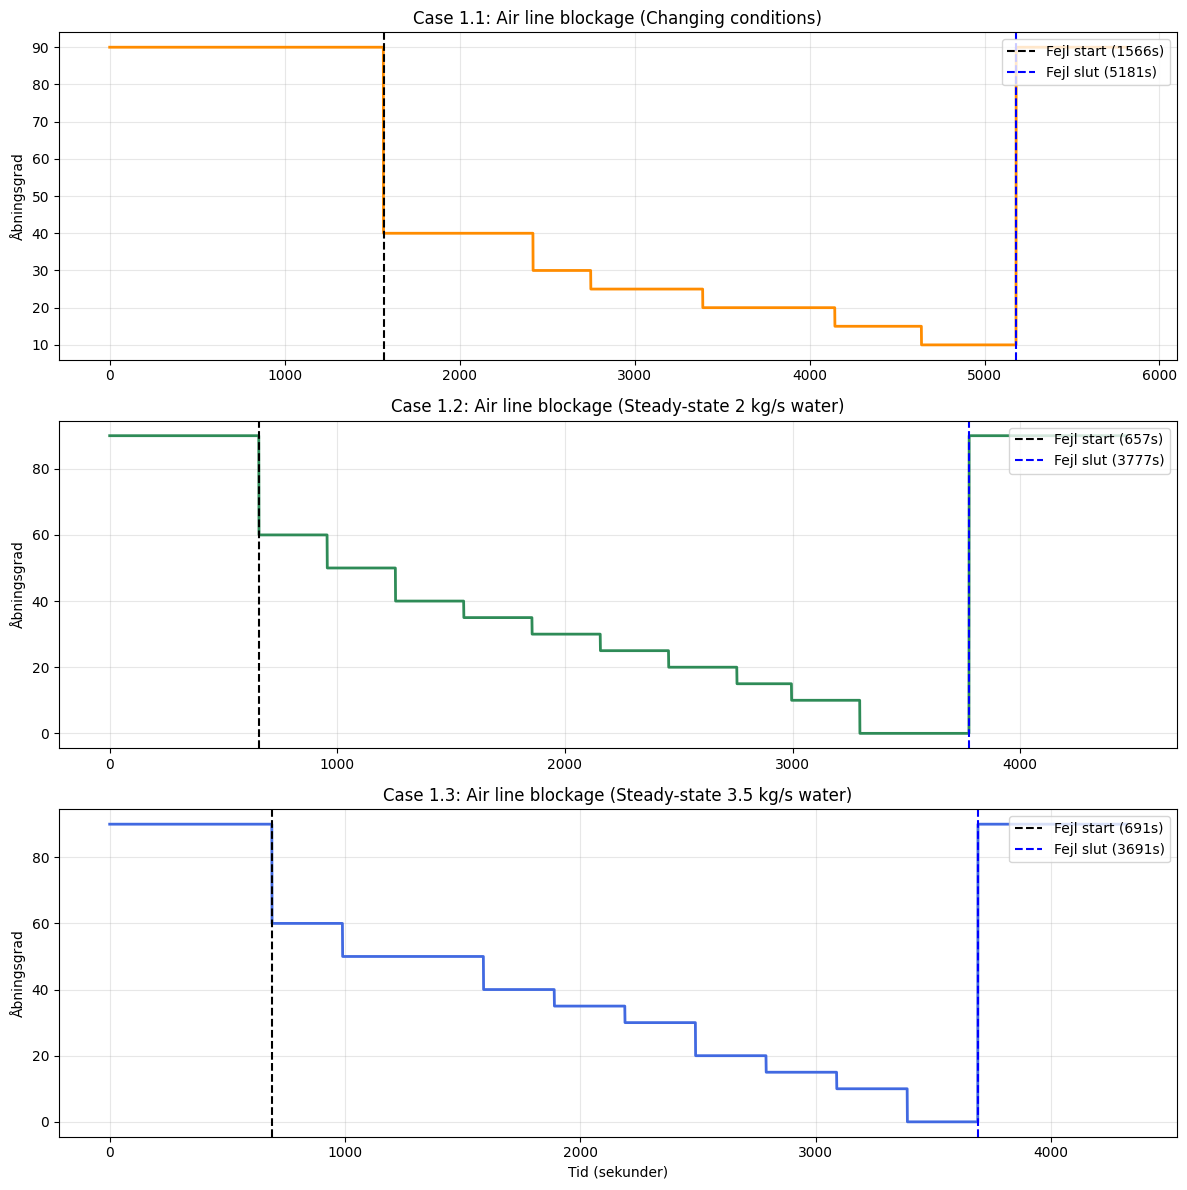

In [3]:
import matplotlib.pyplot as plt

# Vi opretter en figur med 3 subplots under hinanden
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=False)

# --- Plot for Sæt 1.1 (Changing conditions) ---
axes[0].plot(df1_1_gt["Valve_Opening_Percent"], color='darkorange', linewidth=2)
axes[0].axvline(x=1566, color='black', linestyle='--', label='Fejl start (1566s)') 
axes[0].axvline(x=5181, color='blue', linestyle='--', label='Fejl slut (5181s)') 
axes[0].set_title("Case 1.1: Air line blockage (Changing conditions)")
axes[0].set_ylabel("Åbningsgrad")
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# --- Plot for Sæt 1.2 (Steady-state 1) ---
axes[1].plot(df1_2_gt["Valve_Opening_Percent"], color='seagreen', linewidth=2)
axes[1].axvline(x=657, color='black', linestyle='--', label='Fejl start (657s)') 
axes[1].axvline(x=3777, color='blue', linestyle='--', label='Fejl slut (3777s)') 
axes[1].set_title("Case 1.2: Air line blockage (Steady-state 2 kg/s water)")
axes[1].set_ylabel("Åbningsgrad")
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

# --- Plot for Sæt 1.3 (Steady-state 2) ---
axes[2].plot(df1_3_gt["Valve_Opening_Percent"], color='royalblue', linewidth=2)
axes[2].axvline(x=691, color='black', linestyle='--', label='Fejl start (691s)') 
axes[2].axvline(x=3691, color='blue', linestyle='--', label='Fejl slut (3691s)') 
axes[2].set_title("Case 1.3: Air line blockage (Steady-state 3.5 kg/s water)")
axes[2].set_xlabel("Tid (sekunder)")
axes[2].set_ylabel("Åbningsgrad")
axes[2].legend(loc='upper right')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Visualization of operational data
This is only done for data set 1.1 to save room. The fault period is marked on the graphs, but of course this is not available information for the model.

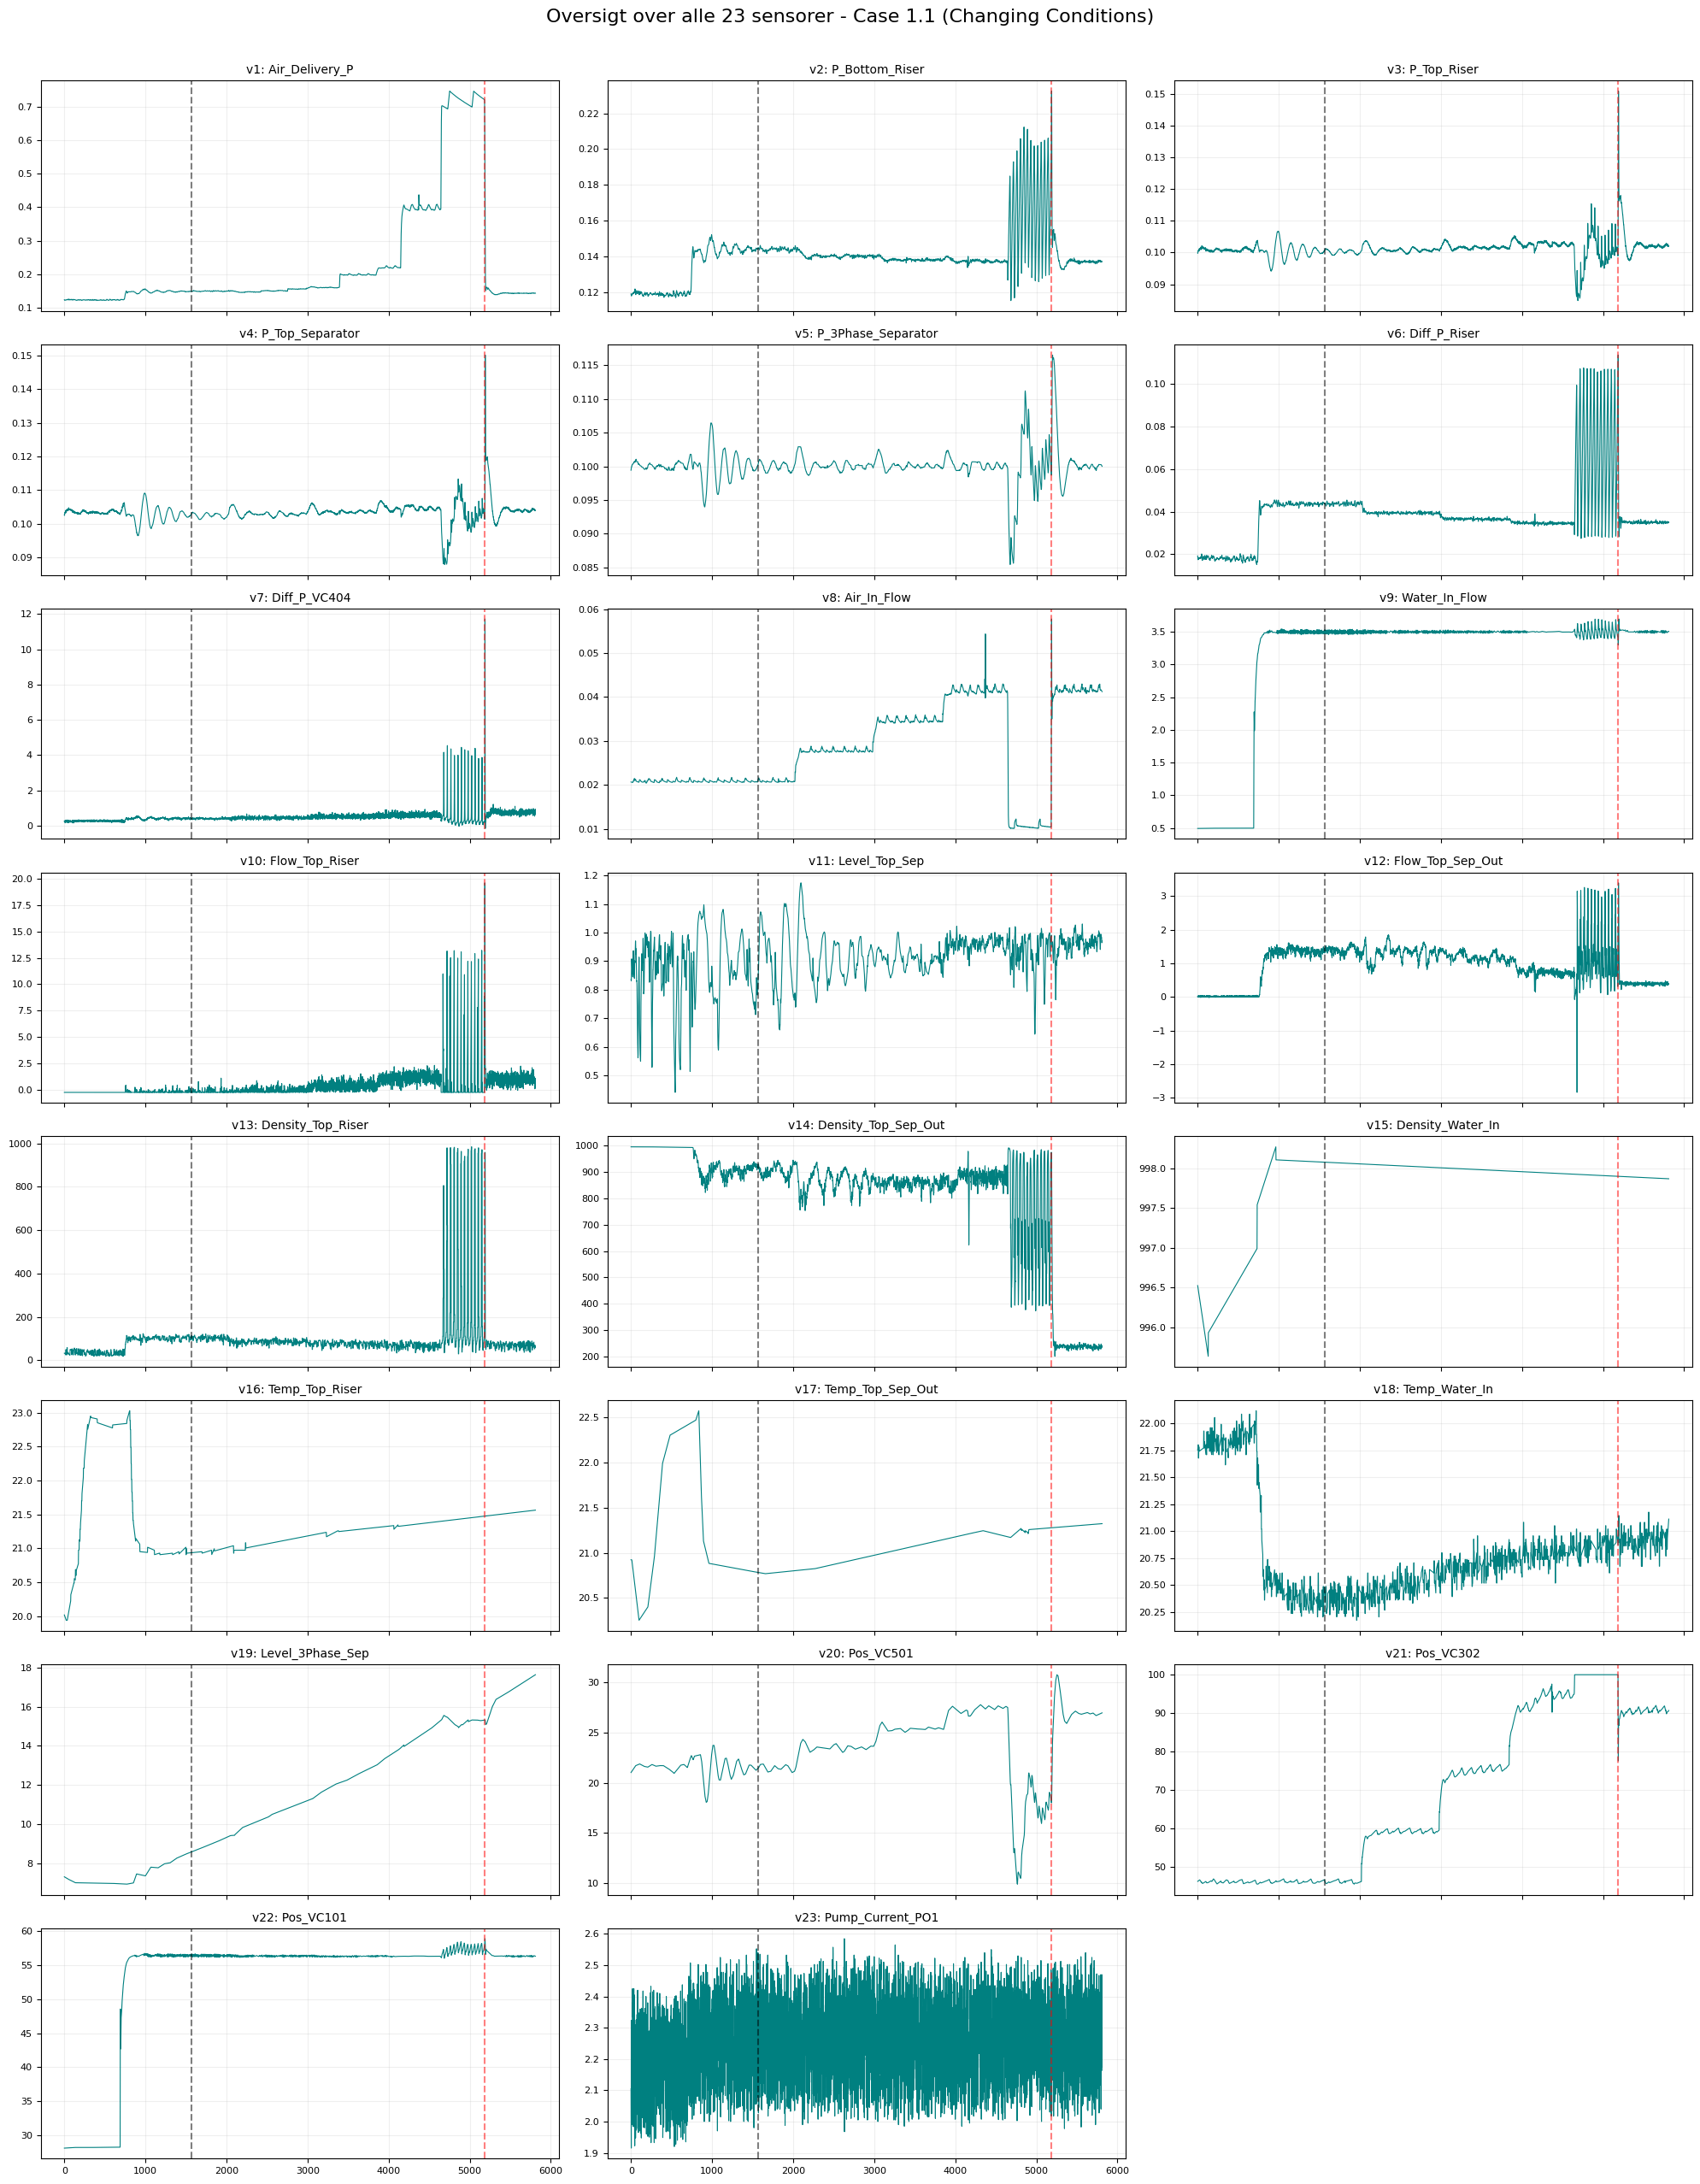

In [4]:
import matplotlib.pyplot as plt

# Vi henter de 23 kolonnenavne vi definerede tidligere
sensors_to_plot = column_names[:23]

# Vi opretter et grid (f.eks. 8 rækker og 3 kolonner for at få plads til alle 23)
fig, axes = plt.subplots(nrows=8, ncols=3, figsize=(20, 25), sharex=True)
axes = axes.flatten() # Gør grid'et fladt så vi kan køre en simpel løkke

for i, sensor in enumerate(sensors_to_plot):
    axes[i].plot(df1_1_sensors[sensor], color='teal', linewidth=0.8)
    
    # Markér fejlens start og slut (Case 1.1: 1566s til 5181s) [cite: 340]
    axes[i].axvline(x=1566, color='black', linestyle='--', alpha=0.5)
    axes[i].axvline(x=5181, color='red', linestyle='--', alpha=0.5)
    
    axes[i].set_title(f"v{i+1}: {sensor}", fontsize=10)
    axes[i].grid(True, alpha=0.2)
    axes[i].tick_params(labelsize=8)

# Skjul de overskydende subplots (da 8x3 = 24, men vi kun har 23 sensorer)
if len(sensors_to_plot) < len(axes):
    for j in range(len(sensors_to_plot), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle("Oversigt over alle 23 sensorer - Case 1.1 (Changing Conditions)", y=1.02, fontsize=16)
plt.show()

## Shewhart control chart 

Der er 23 sensorer, så vi laver ikke Shewhart på alle i første omgang. Pointen med Shewhart er at den er univariat, så vi kan forklare sensor for sensor, om den går ud over kontrolgrænserne. 

Vi træner Shewhart på den del af driften hvor der ikker er fejl. Dette er helt i tråd med undervisningen, hvor tærsklerne antages at komme fra in-control data, de statistiske tærskler bygger på antagelsen om relativt stabile variationer under normal drift. 

Vi bruger samme træningsvinduer som i PCA-delen:
Set 1.1: før 1566
Set 1.2: før 657
Set 1.3: før 691 

Vi bruger den klassiske 3-sigma model først: 

center line: μ

upper control limit: μ+3σ

lower control limit: μ−3σ

"Shewhart charts were used as a univariate statistical monitoring method. Control limits were estimated from healthy training data, and points outside the limits were treated as out-of-control observations."


Vi ønsker at sammenligne Shewhart og PCA eksplicit, hvor man kan lave en lille tabel med f.eks. 
- Første alarmtid
- Antal alarmer før fault-start 
- Antal alarmer under fault-perioden 
- Detection delay 

Så kan vi vise:

- Shewhart er enkel og fortolkelig, men overser nogle fejl og ser kun én sensor ad gangen.
- PCA T^2 samler flere sensorer og kan være bedre til subtile/multivariate ændringer.


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Fault-vinduer
fault_info = {
    "Set_1_1": {"start": 1566, "end": 5181},
    "Set_1_2": {"start": 657,  "end": 3777},
    "Set_1_3": {"start": 691,  "end": 3691},
}

# Datasæt samlet
datasets = {
    "Set_1_1": df1_1_sensors,
    "Set_1_2": df1_2_sensors,
    "Set_1_3": df1_3_sensors,
}

# Healthy træningsdata til Shewhart
train_healthy = {
    "Set_1_1": df1_1_sensors.iloc[:1566].copy(),
    "Set_1_2": df1_2_sensors.iloc[:657].copy(),
    "Set_1_3": df1_3_sensors.iloc[:691].copy(),
}

# Vælg flere sensorer til Shewhart
shewhart_sensors = [
    "Air_Delivery_P",
    "P_Bottom_Riser",
    "Diff_P_VC404",
    "Air_In_Flow",
    "Flow_Top_Riser",
]

def preprocess_series_for_shewhart(train_series, test_series, remove_outliers=True):
    train_series = pd.Series(train_series).astype(float).interpolate().ffill().bfill()
    test_series = pd.Series(test_series).astype(float).interpolate().ffill().bfill()

    if remove_outliers:
        z = ((train_series - train_series.mean()) / train_series.std(ddof=1)).abs()
        train_series = train_series[z < 3]

    return train_series, test_series

def fit_shewhart(train_series, k=3.0):
    mu = train_series.mean()
    sigma = train_series.std(ddof=1)
    ucl = mu + k * sigma
    lcl = mu - k * sigma
    return mu, sigma, lcl, ucl

def shewhart_predict(test_series, lcl, ucl):
    return (test_series < lcl) | (test_series > ucl)

def first_alarm_index(alarm_mask):
    idx = np.where(np.asarray(alarm_mask))[0]
    return int(idx[0]) if len(idx) > 0 else None

def evaluate_alarm(alarm_mask, fault_start, fault_end):
    alarm_mask = np.asarray(alarm_mask).astype(bool)

    pre_fault = alarm_mask[:fault_start]
    in_fault = alarm_mask[fault_start:fault_end+1]

    first_alarm = first_alarm_index(alarm_mask)
    detection_delay = None
    if first_alarm is not None and first_alarm >= fault_start:
        detection_delay = first_alarm - fault_start

    first_alarm_after_fault = first_alarm_index(alarm_mask[fault_start:])
    if first_alarm_after_fault is not None:
        first_alarm_after_fault += fault_start

    return {
        "first_alarm": first_alarm,
        "first_alarm_after_fault": first_alarm_after_fault,
        "detection_delay": None if first_alarm_after_fault is None else first_alarm_after_fault - fault_start,
        "n_alarms_total": int(alarm_mask.sum()),
        "n_alarms_before_fault": int(pre_fault.sum()),
        "n_alarms_in_fault_window": int(in_fault.sum()),
        "false_alarm_rate_before_fault": float(pre_fault.mean()) if len(pre_fault) > 0 else np.nan
    }

In [6]:
# --- Træn Shewhart-modeller for flere sensorer ---

shewhart_models = {}

for sensor in shewhart_sensors:
    pooled_train = pd.concat([
        train_healthy["Set_1_1"][sensor],
        train_healthy["Set_1_2"][sensor],
        train_healthy["Set_1_3"][sensor],
    ], ignore_index=True)

    pooled_train, _ = preprocess_series_for_shewhart(pooled_train, pooled_train, remove_outliers=True)
    mu, sigma, lcl, ucl = fit_shewhart(pooled_train, k=3.0)

    shewhart_models[sensor] = {
        "mu": mu,
        "sigma": sigma,
        "LCL": lcl,
        "UCL": ucl
    }

shewhart_params_df = pd.DataFrame(shewhart_models).T
display(shewhart_params_df)

,mu,sigma,LCL,UCL
Air_Delivery_P,0.139157,0.010876,0.106530,0.171783
P_Bottom_Riser,0.134207,0.010912,0.101472,0.166942
Diff_P_VC404,0.412846,0.149815,-0.036598,0.862289
Air_In_Flow,0.025530,0.008708,-0.000596,0.051655
Flow_Top_Riser,-0.064074,0.320154,-1.024537,0.896388


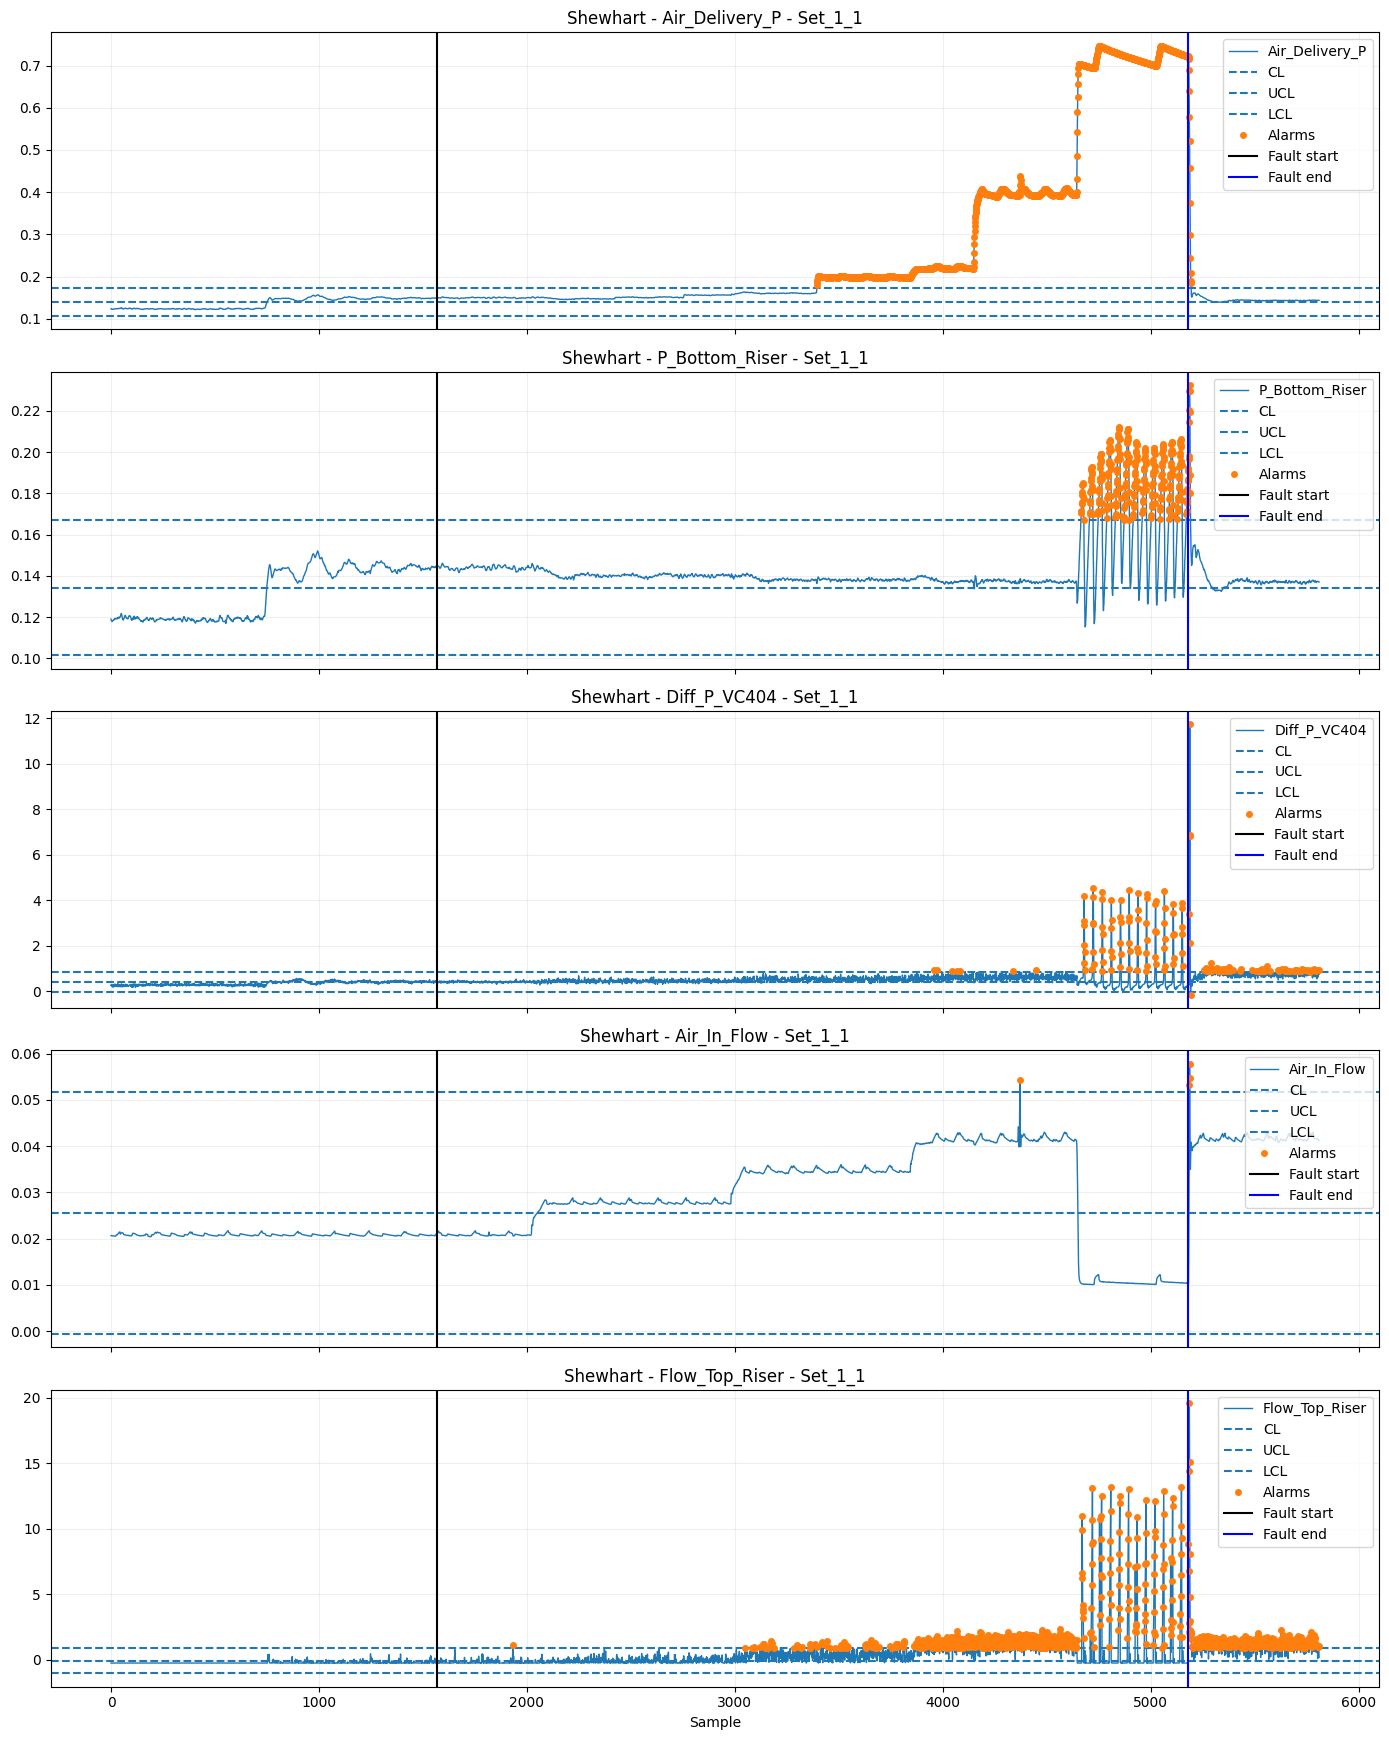

In [7]:
# --- Plot Shewhart charts for Set 1.1 ---

dataset_name = "Set_1_1"
df_test = datasets[dataset_name]
fault_start = fault_info[dataset_name]["start"]
fault_end = fault_info[dataset_name]["end"]

fig, axes = plt.subplots(len(shewhart_sensors), 1, figsize=(14, 3.5 * len(shewhart_sensors)), sharex=True)

if len(shewhart_sensors) == 1:
    axes = [axes]

for ax, sensor in zip(axes, shewhart_sensors):
    _, test_series = preprocess_series_for_shewhart(df_test[sensor], df_test[sensor], remove_outliers=False)

    mu = shewhart_models[sensor]["mu"]
    lcl = shewhart_models[sensor]["LCL"]
    ucl = shewhart_models[sensor]["UCL"]

    alarms = shewhart_predict(test_series, lcl, ucl)

    ax.plot(test_series.values, label=sensor, linewidth=1)
    ax.axhline(mu, linestyle='--', label='CL')
    ax.axhline(ucl, linestyle='--', label='UCL')
    ax.axhline(lcl, linestyle='--', label='LCL')
    ax.plot(np.where(alarms)[0], test_series[alarms], 'o', markersize=4, label='Alarms')

    ax.axvline(fault_start, color='black', linestyle='-', label='Fault start')
    ax.axvline(fault_end, color='blue', linestyle='-', label='Fault end')

    ax.set_title(f'Shewhart - {sensor} - {dataset_name}')
    ax.grid(True, alpha=0.2)
    ax.legend(loc='upper right')

plt.xlabel("Sample")
plt.tight_layout()
plt.show()

Vi laver en samlet alarm: 

Tre niveauer
- OR-rule: alarm hvis mindst én sensor alarmerer
- 2-of-5 rule: alarm hvis mindst 2 sensorer alarmerer samtidig
- 3-of-5 rule: endnu mere konservativ

In [8]:
def shewhart_multisensor_alarm(df_test, shewhart_models, sensors, vote_threshold=1):
    alarm_df = pd.DataFrame(index=df_test.index)

    for sensor in sensors:
        _, test_series = preprocess_series_for_shewhart(df_test[sensor], df_test[sensor], remove_outliers=False)
        lcl = shewhart_models[sensor]["LCL"]
        ucl = shewhart_models[sensor]["UCL"]
        alarm_df[sensor] = shewhart_predict(test_series, lcl, ucl).values

    votes = alarm_df.sum(axis=1)
    combined_alarm = votes >= vote_threshold

    return alarm_df, votes, combined_alarm

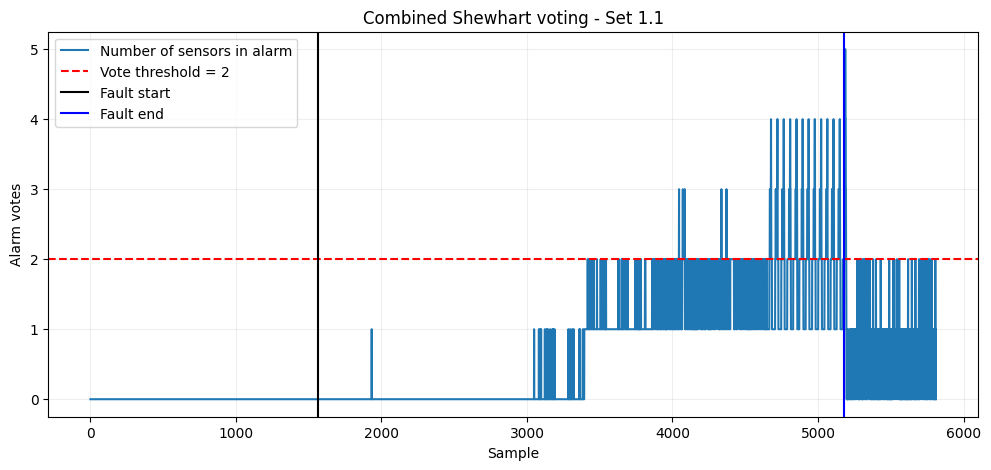

In [9]:
dataset_name = "Set_1_1"
df_test = datasets[dataset_name]
fault_start = fault_info[dataset_name]["start"]
fault_end = fault_info[dataset_name]["end"]

alarm_df_1_1, votes_1_1, shewhart_alarm_1_1 = shewhart_multisensor_alarm(
    df_test, shewhart_models, shewhart_sensors, vote_threshold=2
)

plt.figure(figsize=(12,5))
plt.plot(votes_1_1.values, label='Number of sensors in alarm')
plt.axhline(2, color='r', linestyle='--', label='Vote threshold = 2')
plt.axvline(fault_start, color='black', linestyle='-', label='Fault start')
plt.axvline(fault_end, color='blue', linestyle='-', label='Fault end')
plt.title('Combined Shewhart voting - Set 1.1')
plt.xlabel('Sample')
plt.ylabel('Alarm votes')
plt.grid(True, alpha=0.2)
plt.legend()
plt.show()

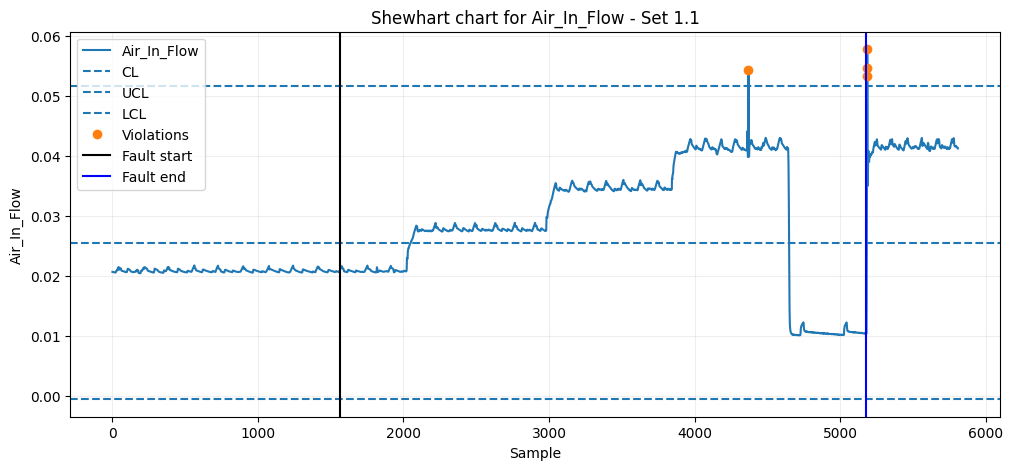

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Vælg sensor
sensor = "Air_In_Flow"

# Healthy training data fra alle tre sæt
train_sensor = pd.concat([
    df1_1_sensors.loc[:1565, sensor],
    df1_2_sensors.loc[:656, sensor],
    df1_3_sensors.loc[:690, sensor]
], ignore_index=True)

# Samme preprocessing-idé som i dit projekt
train_sensor = train_sensor.interpolate().ffill().bfill()

mu = train_sensor.mean()
sigma = train_sensor.std()

UCL = mu + 3 * sigma
LCL = mu - 3 * sigma

# Test på fx Set 1.1
test_sensor = df1_1_sensors[sensor].interpolate().ffill().bfill()
viol = (test_sensor > UCL) | (test_sensor < LCL)

plt.figure(figsize=(12,5))
plt.plot(test_sensor.values, label=sensor)
plt.axhline(mu, linestyle='--', label='CL')
plt.axhline(UCL, linestyle='--', label='UCL')
plt.axhline(LCL, linestyle='--', label='LCL')
plt.plot(np.where(viol)[0], test_sensor[viol], 'o', label='Violations')

plt.axvline(1566, color='black', linestyle='-', label='Fault start')
plt.axvline(5181, color='blue', linestyle='-', label='Fault end')

plt.title(f'Shewhart chart for {sensor} - Set 1.1')
plt.xlabel('Sample')
plt.ylabel(sensor)
plt.grid(True, alpha=0.2)
plt.legend()
plt.show()

In [11]:
def shewhart_chart(train_series, test_series, fault_start=None, fault_end=None, title="Shewhart chart"):
    train_series = pd.Series(train_series).interpolate().ffill().bfill()
    test_series = pd.Series(test_series).interpolate().ffill().bfill()

    mu = train_series.mean()    # My
    sigma = train_series.std()  # Sigma

    UCL = mu + 3*sigma          # μ ± 3σ
    LCL = mu - 3*sigma          # μ ± 3σ

    violations = (test_series > UCL) | (test_series < LCL)

    plt.figure(figsize=(12,5))
    plt.plot(test_series.values, label='Test data')
    plt.axhline(mu, linestyle='--', label='CL')
    plt.axhline(UCL, linestyle='--', label='UCL')
    plt.axhline(LCL, linestyle='--', label='LCL')
    plt.plot(np.where(violations)[0], test_series[violations], 'o', label='Violations')

    if fault_start is not None:
        plt.axvline(fault_start, color='black', linestyle='-', label='Fault start')
    if fault_end is not None:
        plt.axvline(fault_end, color='blue', linestyle='-', label='Fault end')

    plt.title(title)
    plt.xlabel('Sample')
    plt.ylabel('Value')
    plt.grid(True, alpha=0.2)
    plt.legend()
    plt.show()

    return {
        "mu": mu,
        "sigma": sigma,
        "UCL": UCL,
        "LCL": LCL,
        "n_violations": int(violations.sum()),
        "first_violation": int(np.where(violations)[0][0]) if violations.any() else None
    }

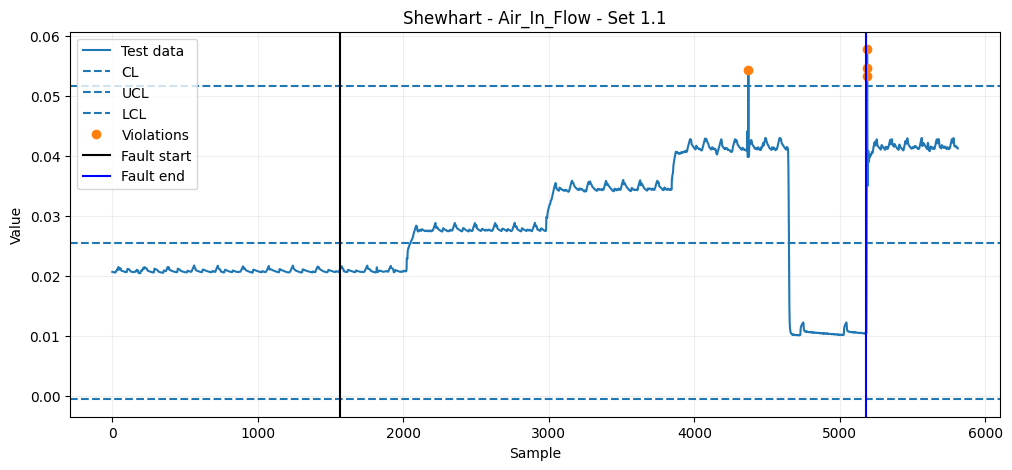

{'mu': np.float64(0.02552971458387383), 'sigma': np.float64(0.008708418189041783), 'UCL': np.float64(0.05165496915099918), 'LCL': np.float64(-0.0005955399832515175), 'n_violations': 4, 'first_violation': 4371}


In [12]:
train_sensor = pd.concat([
    df1_1_sensors.loc[:1565, "Air_In_Flow"],
    df1_2_sensors.loc[:656, "Air_In_Flow"],
    df1_3_sensors.loc[:690, "Air_In_Flow"]
], ignore_index=True)

result = shewhart_chart(
    train_sensor,
    df1_1_sensors["Air_In_Flow"],
    fault_start=1566,
    fault_end=5181,
    title="Shewhart - Air_In_Flow - Set 1.1"
)

print(result)

Der er kun 4 violations i Set 1.1 og den første kommer ved sample 4371, selv om fault starter ved 1566. Det betyder en meget stor detection delay på cirka 2805 samples. Shewhart virker altså som en sen detektor, det fortæller dog ikke om Shewhart er dårlig generelt, kun at den valgte sensor ikke er særlig følsom, eller at de pooled kontrolgrænser er blevet for brede. 

Shewhart chart

"Går denne ene sensor uden for normalområdet?"
- enkel og let at forklare
- bruger statistiske kontrolgrænser fra normal drift
- virker godt, hvis én sensor ændrer sig tydeligt
- kan give false alarms eller overse små ændringer

PCA + T^2

"Afviger hele det multivariate sensormønster fra normal drift?"
- ser på alle sensorer samtidigt
- bedre til korrelerede ændringer
- mindre intuitiv
- kan være mere robust ved komplekse faults

# PCA model 
Generalized with data from all three system configurations, but only the data from before the faults occured. 

This includes removal of outliers and scaling.

In [13]:
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import f
import matplotlib.pyplot as plt

# Tidsstempler for fejl-start jf. artiklen (Tabel 4)
# Set 1.1: 1566s | Set 1.2: 657s | Set 1.3: 691s

# Vi udtrækker de normale rækker (før fejlen starter)
train_1_1 = df1_1_sensors.iloc[:1566]
train_1_2 = df1_2_sensors.iloc[:657]
train_1_3 = df1_3_sensors.iloc[:691]

# Vi samler dem til én robust trænings-matrix
X_train_raw = pd.concat([train_1_1, train_1_2, train_1_3], ignore_index=True)

print(f"Antal normale rækker i puljen: {X_train_raw.shape[0]}")
# Bør give ca. 2914 rækker (1566 + 657 + 691)

# Rensning (Interpolation og outliers)
X_train_clean = X_train_raw.interpolate().ffill().bfill()
z = np.abs(stats.zscore(X_train_clean))
X_train_clean = X_train_clean[(z < 3).all(axis=1)]

# GEM DISSE: De er fundamentet for hele jeres detektionsmodel
train_mu = X_train_clean.mean()
train_sigma = X_train_clean.std()

# Normaliser træningsdata (Z-score)
X_train_scaled = (X_train_clean - train_mu) / train_sigma

Antal normale rækker i puljen: 2914


In [14]:
import numpy as np

# Vi bruger den rensede og skalerede pulje fra før
X = X_train_scaled.values 
n = X.shape[0]  # Antal rækker (ca. 2900)
m = X.shape[1]  # Antal sensorer (23)

# 1. Beregn Kovariansmatrix
# np.cov forventer at variabler er i rækkerne, så vi transponerer med .T
R = np.cov(X.T)

# 2. Find egenværdier og egenvektorer (Svarer til SVD i din MATLAB)
eigenvalues, eigenvectors = np.linalg.eig(R)

# 3. Sortér dem (størst først), da de ikke altid kommer i rækkefølge
idx = eigenvalues.argsort()[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

print("De første 10 egenværdier:")
for i, val in enumerate(eigenvalues[:10]):
    print(f"PC{i+1}: {val:.4f}")


De første 10 egenværdier:
PC1: 8.9282
PC2: 6.1881
PC3: 2.3050
PC4: 1.8312
PC5: 1.0948
PC6: 0.9663
PC7: 0.9169
PC8: 0.1984
PC9: 0.1441
PC10: 0.1065


In [15]:
# 4. Vælg antal hovedkomponenter (a)
a = 7 
P = eigenvectors[:, :a] # Dette er din Loading Matrix (V1 i MATLAB)

# 5. Forbered beregning af T2 (Lambda matrix)
# Vi skal bruge den inverse diagonalmatrix af egenværdierne for de valgte komponenter
Sigma_a_inv = np.diag(1.0 / eigenvalues[:a])

print(f"Model trænet på {n} normale samples med {a} komponenter.")

Model trænet på 2747 normale samples med 7 komponenter.


Statistical Threshold

In [16]:
alpha = 0.05
# F-distributionens kritiske værdi: finv(1-alpha, a, n-a)
f_crit = f.ppf(1 - alpha, a, n - a)

# Beregn T2 tærskel (T2_alpha)
T2_threshold = (a * (n - 1) * (n + 1)) / (n * (n - a)) * f_crit

print(f"Antal komponenter (a): {a}")
print(f"T2 Kontrolgrænse (UCL): {T2_threshold:.4f}")

Antal komponenter (a): 7
T2 Kontrolgrænse (UCL): 14.1264


# Testing the model on test1_1


In [22]:
# Vi tager sensordata fra det fejlbehæftede sæt
X_test_raw = df1_1_sensors.copy() 

# VIGTIGT: Skaler TEST data med TRÆNINGS parametre (mu og sigma)
X_test = (X_test_raw - train_mu) / train_sigma

# Projektion til de valgte komponenter (Scores)
T_test = X_test @ P

# Beregn T2-værdi for hver tidsenhed i test-sættet
# T2 = t * inv(Sigma) * t'
T2_values_1_1 = np.zeros(len(T_test))
for i in range(len(T_test)):
    score = T_test.iloc[i, :].values
    T2_values_1_1[i] = score @ Sigma_a_inv @ score.T

# Results
I jeres projekt fungerer T^2 som et samlet alarmsignal. I stedet for at du skal sidde og holde øje med 23 forskellige grafer for tryk, temperatur og flow, kigger du kun på T^2-grafen.

- Hvis T^2 er lav (under tærsklen), opfører alle 23 sensorer sig præcis, som de gjorde under den normale træningsperiode.

- Hvis T^2 er høj (over tærsklen), er der sket en ændring i systemet, som PCA-modellen ikke genkender som "normal".

Grafen kan laves med en logoritmisk y-akse.

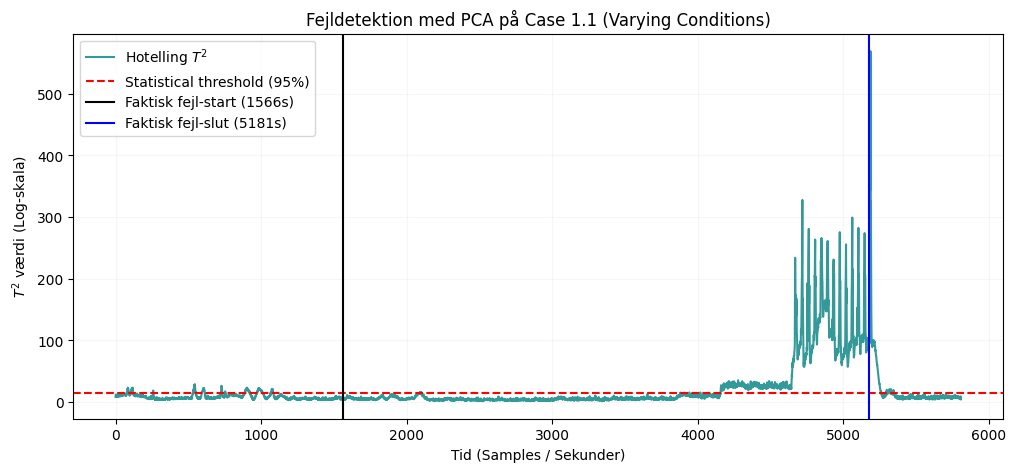

In [23]:
plt.figure(figsize=(12, 5))
plt.plot(T2_values_1_1, label='Hotelling $T^2$', color='teal', alpha=0.8)

# Statistisk tærskel
plt.axhline(y=T2_threshold, color='r', linestyle='--', label='Statistical threshold (95%)')

# Markering af fejl-vinduet jf. Tabel 4 (Case 1.1)
plt.axvline(x=1566, color='black', linestyle='-', label='Faktisk fejl-start (1566s)')
plt.axvline(x=5181, color='blue', linestyle='-', label='Faktisk fejl-slut (5181s)') 

# Gør det pænt
#plt.yscale('log') 
plt.title('Fejldetektion med PCA på Case 1.1 (Varying Conditions)')
plt.xlabel('Tid (Samples / Sekunder)')
plt.ylabel('$T^2$ værdi (Log-skala)')
plt.grid(True, which="both", ls="-", alpha=0.1)
plt.legend(loc='upper left')
plt.show()

# Testing the model on data set 1.2
The model is pretty shitty

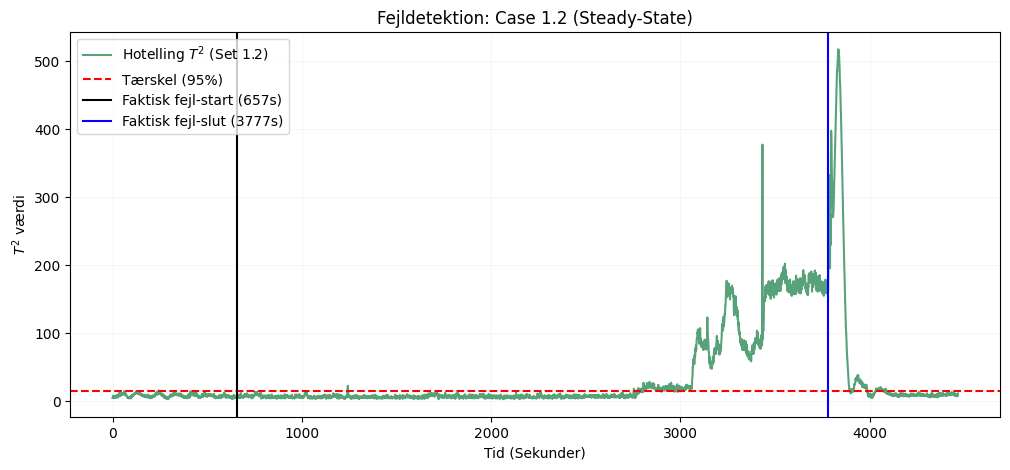

In [19]:
# 1. Hent sensordata fra Set 1.2
X_test_raw_1_2 = df1_2_sensors.copy() 

# 2. Skaler data med de ORIGINALE trænings-parametre fra din pulje
X_test_1_2 = (X_test_raw_1_2 - train_mu) / train_sigma

# 3. Projektion til PCA-rummet (Scores)
T_test_1_2 = X_test_1_2 @ P

# 4. Beregn T2-værdier (Vektoriseret)
T2_values_1_2 = np.sum((T_test_1_2 @ Sigma_a_inv) * T_test_1_2, axis=1)

# 5. Visualisering af resultatet for 1.2
plt.figure(figsize=(12, 5))
plt.plot(T2_values_1_2, label='Hotelling $T^2$ (Set 1.2)', color='seagreen', alpha=0.8)

# Statistisk tærskel fra træningsfasen
plt.axhline(y=T2_threshold, color='r', linestyle='--', label='Tærskel (95%)')

# Markering af fejl-vinduet for Case 1.2 (Tabel 4)
plt.axvline(x=657, color='black', linestyle='-', label='Faktisk fejl-start (657s)')
plt.axvline(x=3777, color='blue', linestyle='-', label='Faktisk fejl-slut (3777s)') 

#plt.yscale('log')
plt.title('Fejldetektion: Case 1.2 (Steady-State)')
plt.xlabel('Tid (Sekunder)')
plt.ylabel('$T^2$ værdi')
plt.grid(True, which="both", ls="-", alpha=0.1)
plt.legend(loc='upper left')
plt.show()

# Testing the model on data set 1.3
The model is pretty shitty

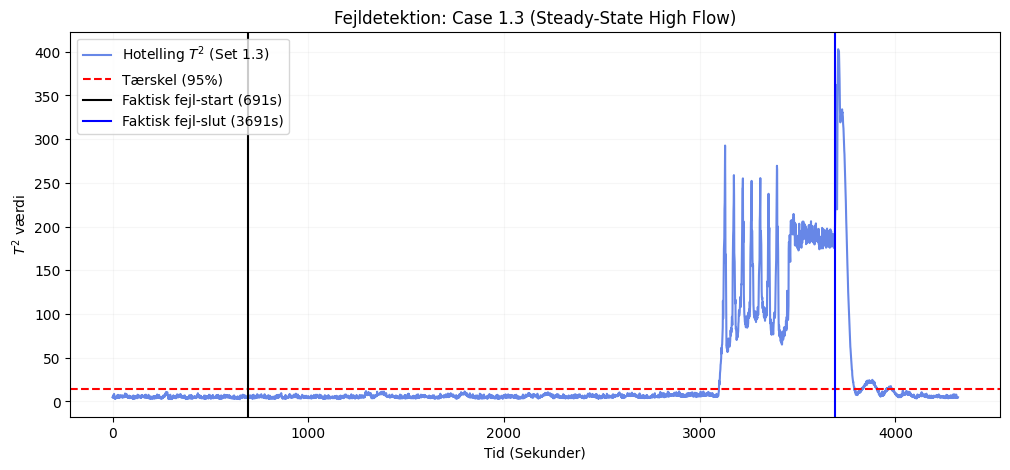

In [20]:
# 1. Hent sensordata fra Set 1.3
X_test_raw_1_3 = df1_3_sensors.copy() 

# 2. Skaler data med de ORIGINALE trænings-parametre (mu og sigma fra din pulje)
# RETTET: Sørg for at bruge _1_3 her
X_test_1_3 = (X_test_raw_1_3 - train_mu) / train_sigma

# 3. Projektion til PCA-rummet (Scores)
T_test_1_3 = X_test_1_3 @ P

# 4. Beregn T2-værdier (Vektoriseret)
T2_values_1_3 = np.sum((T_test_1_3 @ Sigma_a_inv) * T_test_1_3, axis=1)

# 5. Visualisering af resultatet for 1.3
plt.figure(figsize=(12, 5))
plt.plot(T2_values_1_3, label='Hotelling $T^2$ (Set 1.3)', color='royalblue', alpha=0.8)

# Statistisk tærskel
plt.axhline(y=T2_threshold, color='r', linestyle='--', label='Tærskel (95%)')

# Markering af fejl-vinduet for Case 1.3 (Tabel 4)
plt.axvline(x=691, color='black', linestyle='-', label='Faktisk fejl-start (691s)')
plt.axvline(x=3691, color='blue', linestyle='-', label='Faktisk fejl-slut (3691s)') 

#plt.yscale('log')
plt.title('Fejldetektion: Case 1.3 (Steady-State High Flow)')
plt.xlabel('Tid (Sekunder)')
plt.ylabel('$T^2$ værdi')
plt.grid(True, which="both", ls="-", alpha=0.1)
plt.legend(loc='upper left')
plt.show()

# To do
- Vi skal beslutte om vi vil træne modellen på alt sundt driftsdata (so vi gør), eller om vi hellere vil lave én test ad gangen. Artikeln bruger det hele. 

## Sammenligning af Shewhart og PCA

In [24]:
# PCA alarm masks
pca_alarm_1_1 = np.asarray(T2_values_1_1 > T2_threshold)
pca_alarm_1_2 = np.asarray(T2_values_1_2 > T2_threshold)
pca_alarm_1_3 = np.asarray(T2_values_1_3 > T2_threshold)

Sammenligner alle tre sæt

In [25]:
# --- Sammenligning: Shewhart vs PCA ---

comparison_rows = []

pca_alarm_dict = {
    "Set_1_1": pca_alarm_1_1,
    "Set_1_2": pca_alarm_1_2,
    "Set_1_3": pca_alarm_1_3,
}

for dataset_name, df_test in datasets.items():
    fault_start = fault_info[dataset_name]["start"]
    fault_end = fault_info[dataset_name]["end"]

    # Shewhart combined alarm
    alarm_df, votes, shewhart_alarm = shewhart_multisensor_alarm(
        df_test, shewhart_models, shewhart_sensors, vote_threshold=2
    )

    shewhart_metrics = evaluate_alarm(shewhart_alarm, fault_start, fault_end)
    pca_metrics = evaluate_alarm(pca_alarm_dict[dataset_name], fault_start, fault_end)

    comparison_rows.append({
        "Dataset": dataset_name,
        "Model": "Shewhart (2-of-5)",
        **shewhart_metrics
    })

    comparison_rows.append({
        "Dataset": dataset_name,
        "Model": "PCA T2",
        **pca_metrics
    })

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)

,Dataset,Model,first_alarm,first_alarm_after_fault,detection_delay,n_alarms_total,n_alarms_before_fault,n_alarms_in_fault_window,false_alarm_rate_before_fault
0,Set_1_1,Shewhart (2-of-5),3417,3417,1851,960,0,904,0.000000
1,Set_1_1,PCA T2,56,2080,514,1362,188,1048,0.120051
2,Set_1_2,Shewhart (2-of-5),2462,2462,1805,732,0,692,0.000000
3,Set_1_2,PCA T2,63,1026,369,1259,6,1001,0.009132
4,Set_1_3,Shewhart (2-of-5),3111,3111,2420,488,0,446,0.000000
5,Set_1_3,PCA T2,3099,3099,2408,789,0,593,0.000000


In [26]:
# --- Sensor-for-sensor Shewhart evaluering ---

sensor_rows = []

for dataset_name, df_test in datasets.items():
    fault_start = fault_info[dataset_name]["start"]
    fault_end = fault_info[dataset_name]["end"]

    for sensor in shewhart_sensors:
        _, test_series = preprocess_series_for_shewhart(df_test[sensor], df_test[sensor], remove_outliers=False)
        lcl = shewhart_models[sensor]["LCL"]
        ucl = shewhart_models[sensor]["UCL"]

        alarms = shewhart_predict(test_series, lcl, ucl)
        metrics = evaluate_alarm(alarms, fault_start, fault_end)

        sensor_rows.append({
            "Dataset": dataset_name,
            "Sensor": sensor,
            **metrics
        })

sensor_eval_df = pd.DataFrame(sensor_rows)
display(sensor_eval_df.sort_values(["Dataset", "detection_delay", "n_alarms_before_fault"]))

,Dataset,Sensor,first_alarm,first_alarm_after_fault,detection_delay,n_alarms_total,n_alarms_before_fault,n_alarms_in_fault_window,false_alarm_rate_before_fault
4,Set_1_1,Flow_Top_Riser,1933.0,1933.0,367.0,1115,0,742,0.000000
0,Set_1_1,Air_Delivery_P,3395.0,3395.0,1829.0,1800,0,1787,0.000000
2,Set_1_1,Diff_P_VC404,3960.0,3960.0,2394.0,169,0,84,0.000000
3,Set_1_1,Air_In_Flow,4371.0,4371.0,2805.0,4,0,1,0.000000
1,Set_1_1,P_Bottom_Riser,4666.0,4666.0,3100.0,278,0,268,0.000000
9,Set_1_2,Flow_Top_Riser,6.0,658.0,1.0,1601,102,1224,0.155251
5,Set_1_2,Air_Delivery_P,2460.0,2460.0,1803.0,1362,0,1318,0.000000
6,Set_1_2,P_Bottom_Riser,3238.0,3238.0,2581.0,405,0,381,0.000000
7,Set_1_2,Diff_P_VC404,3783.0,3783.0,3126.0,41,0,0,0.000000
8,Set_1_2,Air_In_Flow,NaN,NaN,NaN,0,0,0,0.000000


A Shewhart-based baseline was constructed using multiple individual sensors and control limits estimated from healthy training data. To reduce sensitivity to isolated sensor noise, a voting strategy was introduced, where an alarm was raised only when at least two sensors were simultaneously out of control. This baseline was then compared with the PCA-based Hotelling’s T
2
 model using detection delay, number of alarms before fault onset, and number of alarms during the fault interval.

The Shewhart model is easier to interpret because each alarm can be traced back to a specific sensor, whereas PCA T
2
 provides a multivariate view of process deviation. However, PCA may detect correlated changes earlier, while Shewhart can be more transparent but also more dependent on sensor selection.